# **"BioGen": Bacteria Toxicity Classifier**

### **The Scenario**
You are a computational biologist at "BioGen," a lab studying harmful bacteria strains. You need to classify bacterial samples as **"Safe"** or **"Toxic"** based on two automated measurements:

1.  **Colony Population:** Measured in **number of cells** (Large integer values, e.g., 50,000).
2.  **Toxin Secretion Level:** Measured in **micrograms** (Tiny decimal values, e.g., 0.5 µg).

You are using a **K-Nearest Neighbors (KNN)** algorithm to flag dangerous samples. However, your algorithm is failing to detect toxic samples, labeling them "Safe" even when their toxin levels are lethally high.

**Your Goal:** Use Feature Engineering and Linear Transformations ($x' = Wx$) to fix the scaling issue so the algorithm "sees" the toxin data.

---

### **The Data Problem**
Here is your training data. Notice the massive difference in scale between the two features.

| Sample ID | Population ($x_1$) | Toxin Level ($x_2$) | Label ($y$) |
| :--- | :--- | :--- | :--- |
| A | 50,000 | 0.1 | Safe |
| B | 50,100 | 0.2 | Safe |
| C | 49,900 | 0.1 | Safe |
| D | 52,000 | 0.1 | Safe |
| E | 50,000 | 0.9 | **Toxic** |
| F | 49,950 | 0.8 | **Toxic** |

**New Unknown Sample X:**
* **Population:** 50,100
* **Toxin Level:** 0.9 (Very High!)

Intuitively, Sample X has high toxin levels like Sample E, so it should be **Toxic**.
However, let's look at the math.

### **Knowledge Check**

**Question 1:** We calculate the Euclidean Distance between Sample X (50100, 0.9) and two neighbors:
* **Neighbor B (Safe):** (50100, 0.2)
* **Neighbor E (Toxic):** (50000, 0.9)

Which statement is true about the distances?

A) Distance to E is smaller because toxin levels match perfectly (0.9 vs 0.9).

B) Distance to B is smaller because the Population difference is 0, whereas the Population difference to E is 100.

C) The distances are exactly equal.

D) Toxin level is the dominant feature.

# Put your answer and explanation here...

### **Feature Transformation ($x' = Wx$)**

The Population numbers (thousands) are "drowning out" the Toxin numbers (decimals). We need to normalize this.
We can define a transformation $x' = Wx$ where $W$ is a scaling matrix.

**Question 2:** We want to scale **Population down by 100,000** and scale **Toxin Level up by 10**.
If input $x = \begin{bmatrix} \text{Pop} \\ \text{Toxin} \end{bmatrix}$, select the correct matrix $W$.

A) $W = \begin{bmatrix} 100,000 & 0 \\ 0 & 0.1 \end{bmatrix}$

B) $W = \begin{bmatrix} 0.00001 & 0 \\ 0 & 10 \end{bmatrix}$

C) $W = \begin{bmatrix} 10 & 0 \\ 0 & 0.00001 \end{bmatrix}$

D) $W = \begin{bmatrix} 1 & 1 \\ 0 & 1 \end{bmatrix}$

# Put your answer here...

### **Normalization Logic**

**Question 3:** Instead of manually guessing weights, a common technique is **Min-Max Normalization** (scaling to range [0, 1]).
Given a feature vector $x$ with minimum value $x_{min}$ and maximum $x_{max}$, which formula achieves this?

A) $x' = \frac{x - \mu}{\sigma}$

B) $x' = \frac{x - x_{min}}{x_{max} - x_{min}}$

C) $x' = x \times W$

D) $x' = \log(x)$

# Put your answer here...

### **Code Walkthrough: Visualizing the Shift**
Let's code this to see how the "Nearest Neighbors" change before and after transformation.

We will use scilit-learn's KNN Classifier for this exercise. Feel free to play around and try with Min-Max normalization scaling technique for both features.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
# 1. Setup Data: 2 Classes (Safe vs Toxic)
# Feature 0: Population (High Variance), Feature 1: Toxin (Low Variance)
# Let's generate 20 data points for better visualization
np.random.seed(42)

# Safe Samples: Pop ~50k, Toxin ~0.1
safe_pop = np.random.normal(50000, 200, 10)
safe_tox = np.random.normal(0.1, 0.05, 10)
safe_data = np.column_stack((safe_pop, safe_tox))

# Toxic Samples: Pop ~50k (Same!), Toxin ~0.9
toxic_pop = np.random.normal(45000, 200, 10)
toxic_tox = np.random.normal(0.9, 0.05, 10)
toxic_data = np.column_stack((toxic_pop, toxic_tox))

X_train = np.vstack((safe_data, toxic_data))
y_train = ['Safe']*10 + ['Toxic']*10

In [ ]:
# New Unknown Sample X (High Toxin)
X_new = np.array([[50050, 0.85]])

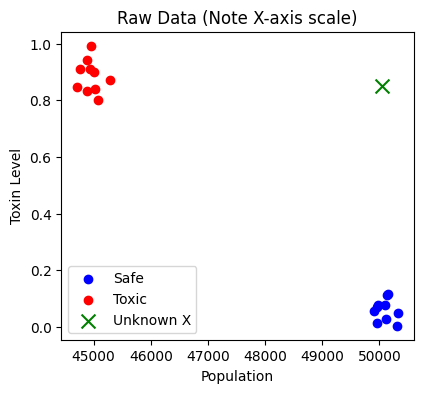

In [ ]:
# 2. Visualize RAW Data
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.scatter(X_train[:10, 0], X_train[:10, 1], c='blue', label='Safe')
plt.scatter(X_train[10:, 0], X_train[10:, 1], c='red', label='Toxic')
plt.scatter(X_new[:, 0], X_new[:, 1], c='green', marker='x', s=100, label='Unknown X')
plt.title("Raw Data (Note X-axis scale)")
plt.xlabel("Population")
plt.ylabel("Toxin Level")
plt.legend()

In [ ]:
# 3. Train KNN on RAW Data
knn_raw = KNeighborsClassifier(n_neighbors=3)
knn_raw.fit(X_train, y_train)
pred_raw = knn_raw.predict(X_new)
print(f"Prediction on RAW Data: {pred_raw[0]}")

Prediction on RAW Data: Safe


In [ ]:
# 4. Apply Transformation Matrix W
# Scale Pop by 0.00001, Toxin by 10
W = np.array([
    [0.00001, 0],
    [0,      10]
])

X_transformed = X_train @ W.T
X_new_transformed = X_new @ W.T

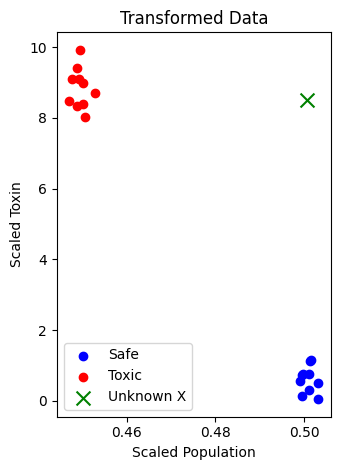

In [ ]:
# 5. Visualize Transformed Data
plt.subplot(1, 2, 2)
plt.scatter(X_transformed[:10, 0], X_transformed[:10, 1], c='blue', label='Safe')
plt.scatter(X_transformed[10:, 0], X_transformed[10:, 1], c='red', label='Toxic')
plt.scatter(X_new_transformed[:, 0], X_new_transformed[:, 1], c='green', marker='x', s=100, label='Unknown X')
plt.title("Transformed Data")
plt.xlabel("Scaled Population")
plt.ylabel("Scaled Toxin")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# 6. Train KNN on TRANSFORMED Data
knn_trans = KNeighborsClassifier(n_neighbors=3)
knn_trans.fit(X_transformed, y_train)
pred_trans = knn_trans.predict(X_new_transformed)
print(f"Prediction on TRANSFORMED Data: {pred_trans[0]}")

Prediction on TRANSFORMED Data: Toxic
